In [1]:
import pandas as pd
import numpy as np

# Use your exact local file path
file_path = r"C:\Users\mukhe\OneDrive\Documents\Jobaaj_DA Projects\Google App Data Analysis\Dataset\googleplaystore.csv"

print("Starting Data Preprocessing...")

# Load the dataset
df = pd.read_csv(file_path)

# 1. Handle Missing Values
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Type'] = df['Type'].fillna(df['Type'].mode()[0])
df['Content Rating'] = df['Content Rating'].fillna(df['Content Rating'].mode()[0])
df['Current Ver'] = df['Current Ver'].fillna('Varies with device')
df['Android Ver'] = df['Android Ver'].fillna('Varies with device')

# 2. Convert Data Types (Installs, Price, and Reviews to numerical values)
df['Installs'] = df['Installs'].astype(str).str.replace('+', '', regex=False).str.replace(',', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce').fillna(0).astype(int)

df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').fillna(0.0)

df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce').fillna(0).astype(int)

# Clean and convert Size to numeric (converting KB to MB to normalize it)
def clean_size(size_val):
    size_str = str(size_val).upper().strip()
    if 'M' in size_str:
        return pd.to_numeric(size_str.replace('M', ''), errors='coerce')
    elif 'K' in size_str:
        return pd.to_numeric(size_str.replace('K', ''), errors='coerce') / 1024
    return np.nan

df['Size'] = df['Size'].apply(clean_size)
df['Size'] = df['Size'].fillna(df['Size'].median())

# 3. Remove Duplicates
df = df.drop_duplicates(subset=['App'])

# 4. Standardize Text fields
df['Category'] = df['Category'].astype(str).str.upper().str.strip()
df['Genres'] = df['Genres'].astype(str).str.strip()

# 5. Date Formatting (Convert Last Updated column to datetime format)
df['Last Updated'] = pd.to_datetime(df['Last Updated'].astype(str).str.strip(), format='%B %d, %Y', errors='coerce')
df['Last Updated'] = df['Last Updated'].fillna(df['Last Updated'].mode()[0])

print("Data Preprocessing Completed successfully!\n")

Starting Data Preprocessing...
Data Preprocessing Completed successfully!



### Basic Level Topics

In [2]:
# Print statement before the solution as requested
print("Basic Level - Topic 1: Average Rating of Apps")

# Calculate and print the mean of the Rating column
avg_rating = df['Rating'].mean()
print(f"The average rating of apps in the dataset is: {avg_rating:.2f}")


Basic Level - Topic 1: Average Rating of Apps
The average rating of apps in the dataset is: 4.19


In [3]:
# Print statement before the solution
print("Basic Level - Topic 2: Number of Unique Categories")

# Find unique values in the Category column
unique_categories = df['Category'].nunique()
print(f"There are {unique_categories} unique categories of apps in the dataset.")

Basic Level - Topic 2: Number of Unique Categories
There are 34 unique categories of apps in the dataset.


Basic Level - Topic 3: Distribution of App Sizes
count    9660.000000
mean       19.454841
std        20.541449
min         0.008301
25%         5.300000
50%        13.000000
75%        25.000000
max       100.000000
Name: Size, dtype: float64


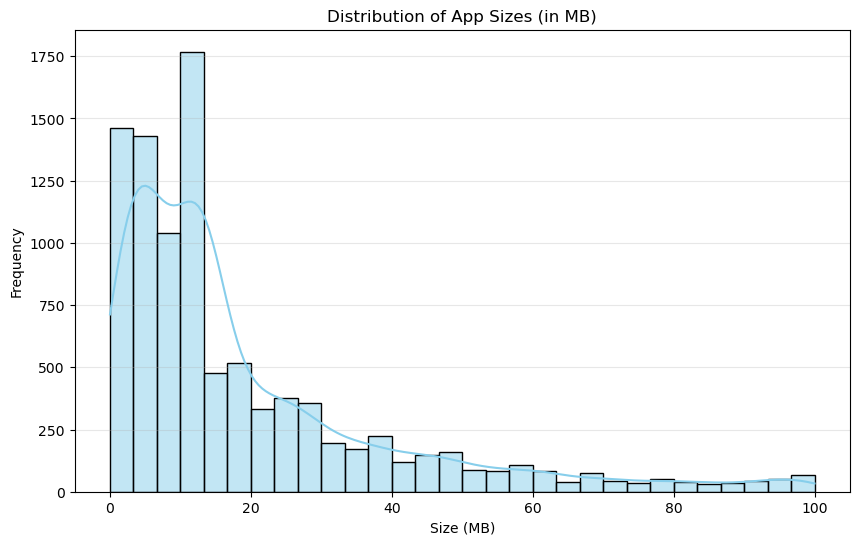

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print statement before the solution
print("Basic Level - Topic 3: Distribution of App Sizes")

# Output text summary stats of app sizes
print(df['Size'].describe())

# Generate a histogram to visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Size'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of App Sizes (in MB)')
plt.xlabel('Size (MB)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [5]:
# Print statement before the solution
print("Basic Level - Topic 4: Count of Free vs Paid Apps")

# Count occurrences of each value in the Type column
type_counts = df['Type'].value_counts()
print(type_counts)

Basic Level - Topic 4: Count of Free vs Paid Apps
Type
Free    8903
Paid     756
0          1
Name: count, dtype: int64


In [6]:
# Print statement before the solution
print("Basic Level - Topic 5: Most Common Content Rating")

# Find the mode of the Content Rating column
most_common_content = df['Content Rating'].mode()[0]
print(f"The most common content rating for apps is: {most_common_content}")

Basic Level - Topic 5: Most Common Content Rating
The most common content rating for apps is: Everyone


In [7]:
# Print statement before the solution
print("Basic Level - Topic 6: Top 5 Most Installed Apps")

# Sort by Installs (and break ties with Reviews) to get the top 5
top_5_apps = df.sort_values(by=['Installs', 'Reviews'], ascending=[False, False]).head(5)
print(top_5_apps[['App', 'Category', 'Installs', 'Reviews']])

Basic Level - Topic 6: Top 5 Most Installed Apps
                                           App       Category    Installs  \
2544                                  Facebook         SOCIAL  1000000000   
336                         WhatsApp Messenger  COMMUNICATION  1000000000   
2545                                 Instagram         SOCIAL  1000000000   
335   Messenger – Text and Video Chat for Free  COMMUNICATION  1000000000   
1654                            Subway Surfers           GAME  1000000000   

       Reviews  
2544  78158306  
336   69119316  
2545  66577313  
335   56642847  
1654  27722264  


In [8]:
# Print statement before the solution
print("Basic Level - Topic 7: Apps Rated 4.0 and Above")

# Filter rows where Rating is greater than or equal to 4.0
high_rated_apps = df[df['Rating'] >= 4.0]
print(f"Number of apps with a rating of 4.0 and above: {len(high_rated_apps)}")

Basic Level - Topic 7: Apps Rated 4.0 and Above
Number of apps with a rating of 4.0 and above: 7750


In [9]:
# Print statement before the solution
print("Basic Level - Topic 8: Average Reviews for Free vs Paid Apps")

# Group by the 'Type' column and calculate the mean of 'Reviews'
avg_reviews_by_type = df.groupby('Type')['Reviews'].mean()
print(avg_reviews_by_type)

Basic Level - Topic 8: Average Reviews for Free vs Paid Apps
Type
0            0.000000
Free    234243.688532
Paid      8724.887566
Name: Reviews, dtype: float64


In [10]:
# Print statement before the solution
print("Basic Level - Topic 9: Average App Size by Category")

# Group by Category and find the mean of the Size column (in MB)
avg_size_by_category = df.groupby('Category')['Size'].mean().sort_values(ascending=False)
print(avg_size_by_category)

Basic Level - Topic 9: Average App Size by Category
Category
GAME                   39.277910
FAMILY                 26.366840
SPORTS                 22.697150
TRAVEL_AND_LOCAL       21.850944
PARENTING              21.561667
ENTERTAINMENT          19.301961
AUTO_AND_VEHICLES      19.208948
HEALTH_AND_FITNESS     19.178044
FOOD_AND_DRINK         18.888393
MEDICAL                18.765727
EDUCATION              17.529888
FINANCE                16.785481
MAPS_AND_NAVIGATION    15.750777
HOUSE_AND_HOME         15.488387
DATING                 15.474372
SOCIAL                 15.359628
VIDEO_PLAYERS          15.175839
PHOTOGRAPHY            15.106277
SHOPPING               15.071717
LIFESTYLE              14.669562
EVENTS                 13.858221
BUSINESS               13.776074
BEAUTY                 13.705660
COMICS                 13.695149
BOOKS_AND_REFERENCE    13.117149
1.9                    13.000000
WEATHER                12.773017
NEWS_AND_MAGAZINES     12.580712
PRODUCTIVITY   

In [11]:
# Print statement before the solution
print("Basic Level - Topic 10: Apps Last Updated in 2018")

# Filter the dataframe for entries where the Last Updated year equals 2018
apps_updated_2018 = df[df['Last Updated'].dt.year == 2018]
print(f"Number of apps last updated in 2018: {len(apps_updated_2018)}")

Basic Level - Topic 10: Apps Last Updated in 2018
Number of apps last updated in 2018: 6285


### Medium Level Topics

In [12]:
# Print statement before the solution
print("Medium Level - Topic 1: Correlation Between Installs and App Rating")

# Calculate the correlation coefficient
correlation = df['Installs'].corr(df['Rating'])
print(f"The correlation coefficient between installs and rating is: {correlation:.4f}")

Medium Level - Topic 1: Correlation Between Installs and App Rating
The correlation coefficient between installs and rating is: 0.0324


In [13]:
# Print statement before the solution
print("Medium Level - Topic 2: Highest Average Rating by Category")

# Group by Category and find the mean of the Rating column
avg_rating_by_cat = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)
print(avg_rating_by_cat)

Medium Level - Topic 2: Highest Average Rating by Category
Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.363866
ART_AND_DESIGN          4.354687
BOOKS_AND_REFERENCE     4.334234
PERSONALIZATION         4.325532
PARENTING               4.300000
BEAUTY                  4.283019
SOCIAL                  4.255230
HEALTH_AND_FITNESS      4.251736
GAME                    4.249948
WEATHER                 4.248101
SHOPPING                4.237624
SPORTS                  4.232923
LIBRARIES_AND_DEMO      4.207143
PRODUCTIVITY            4.206150
AUTO_AND_VEHICLES       4.205882
MEDICAL                 4.202025
FAMILY                  4.194378
FOOD_AND_DRINK          4.192857
COMICS                  4.185714
HOUSE_AND_HOME          4.174324
BUSINESS                4.173810
PHOTOGRAPHY             4.166548
NEWS_AND_MAGAZINES      4.156693
COMMUNICATION           4.154921
FINANCE                 4.138551
ENTERTAINMENT           4.135294
LIFESTYL

In [14]:
# Print statement before the solution
print("Medium Level - Topic 3: Effect of Price on Average Rating for Paid Apps")

# Filter for paid apps only
paid_apps = df[df['Type'] == 'Paid']

# Group by Price and calculate the mean rating
price_impact = paid_apps.groupby('Price')['Rating'].mean().reset_index()
print(price_impact.sort_values(by='Price'))

Medium Level - Topic 3: Effect of Price on Average Rating for Paid Apps
     Price    Rating
0     0.99  4.298621
1     1.00  4.400000
2     1.04  4.300000
3     1.20  4.200000
4     1.26  4.300000
..     ...       ...
86  379.99  2.900000
87  389.99  3.600000
88  394.99  4.300000
89  399.99  4.033333
90  400.00  3.600000

[91 rows x 2 columns]


Medium Level - Topic 4: Distribution of App Ratings Across Different Content Ratings


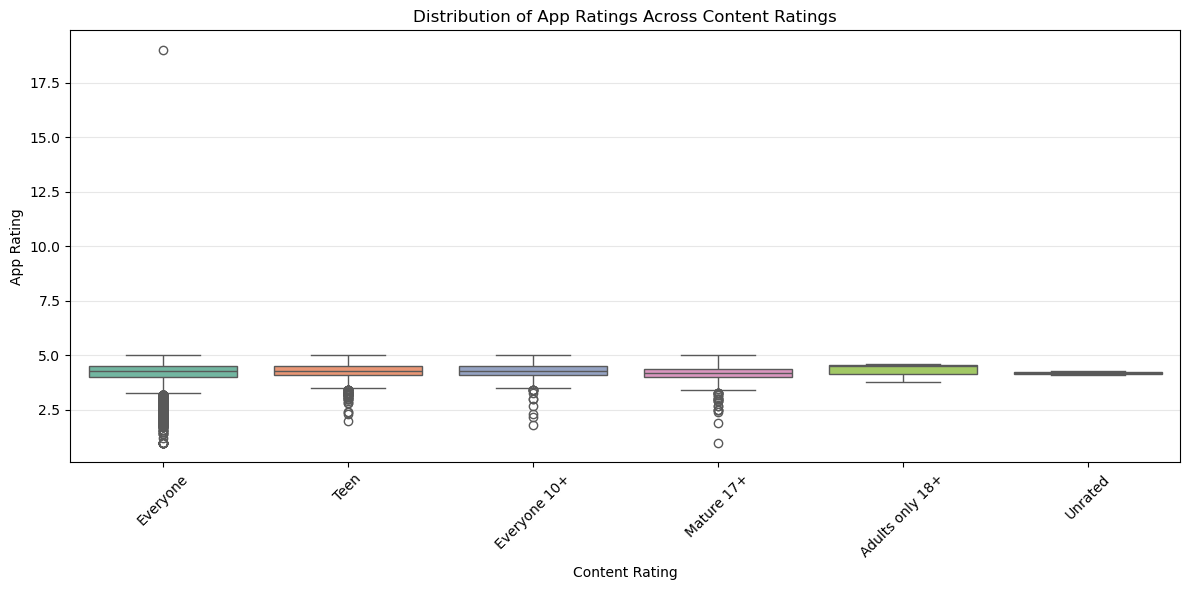

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print statement before the solution
print("Medium Level - Topic 4: Distribution of App Ratings Across Different Content Ratings")

# Updated syntax with hue and legend=False to prevent the warning
plt.figure(figsize=(12, 6))
sns.boxplot(x='Content Rating', y='Rating', data=df, hue='Content Rating', palette='Set2', legend=False)
plt.title('Distribution of App Ratings Across Content Ratings')
plt.xlabel('Content Rating')
plt.ylabel('App Rating')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Print statement before the solution
print("Medium Level - Topic 5: Genres with Over 1 Million Installs")

# Filter the data for apps with Installs greater than 1 million
high_install_apps = df[df['Installs'] > 1000000]

# Group by Genres and count the number of apps, then sort descending
genre_distribution = high_install_apps.groupby('Genres')['App'].count().sort_values(ascending=False)
print(genre_distribution)

Medium Level - Topic 5: Genres with Over 1 Million Installs
Genres
Tools                               172
Action                              128
Photography                         123
Communication                        99
Productivity                         91
                                   ... 
Entertainment;Creativity              1
Entertainment;Action & Adventure      1
Educational                           1
Educational;Creativity                1
Entertainment;Pretend Play            1
Name: App, Length: 88, dtype: int64


In [17]:
# Print statement before the solution
print("Medium Level - Topic 6: App Update Frequency Lifecycle Analysis")

# Establish the benchmark baseline date from the dataset
max_date = df['Last Updated'].max()

# Compute the days elapsed since the last update for each record
df['Days_Since_Last_Update'] = (max_date - df['Last Updated']).dt.days

# Output summary metrics of the update windows
print(df['Days_Since_Last_Update'].describe())

Medium Level - Topic 6: App Update Frequency Lifecycle Analysis
count    9660.000000
mean      281.156108
std       406.761217
min         0.000000
25%        22.000000
50%        96.000000
75%       367.250000
max      3001.000000
Name: Days_Since_Last_Update, dtype: float64


Medium Level - Topic 7: Impact of App Size on the Number of Installs


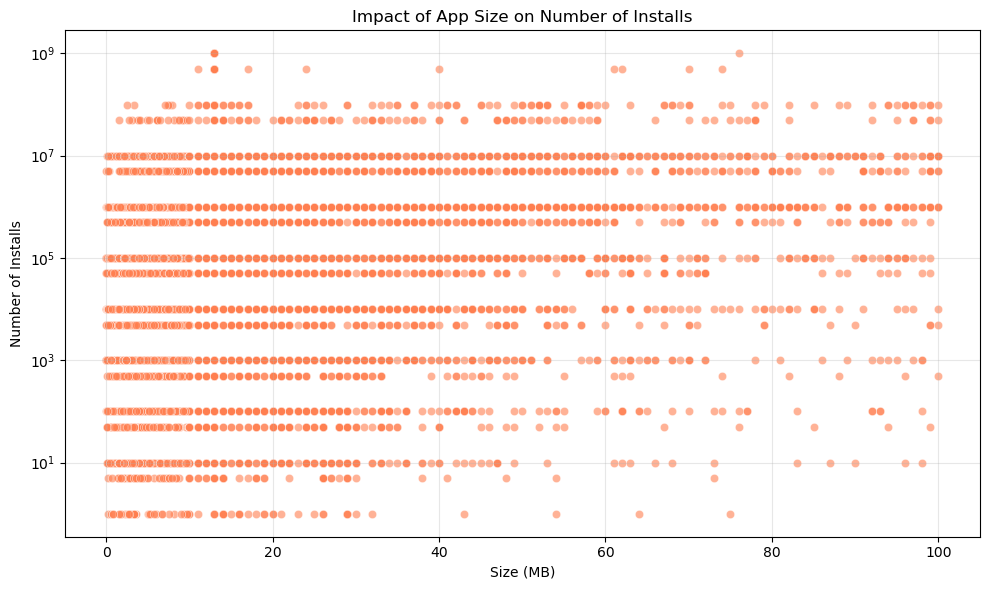

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print statement before the solution
print("Medium Level - Topic 7: Impact of App Size on the Number of Installs")

# Create a scatter plot with Size and Installs
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Installs', data=df, alpha=0.6, color='coral')
plt.title('Impact of App Size on Number of Installs')
plt.xlabel('Size (MB)')
plt.ylabel('Number of Installs')
plt.yscale('log')  # Using log scale due to high variation in install ranges
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Print statement before the solution
print("Medium Level - Topic 8: Apps with the Highest Number of Reviews and Their Ratings")

# Sort the dataset by Reviews descending and select the top 10 rows
top_reviewed_apps = df.sort_values(by='Reviews', ascending=False).head(10)
print(top_reviewed_apps[['App', 'Reviews', 'Rating', 'Installs']])

Medium Level - Topic 8: Apps with the Highest Number of Reviews and Their Ratings
                                                    App   Reviews  Rating  \
2544                                           Facebook  78158306     4.1   
336                                  WhatsApp Messenger  69119316     4.4   
2545                                          Instagram  66577313     4.5   
335            Messenger – Text and Video Chat for Free  56642847     4.0   
1670                                     Clash of Clans  44891723     4.6   
4005            Clean Master- Space Cleaner & Antivirus  42916526     4.7   
1654                                     Subway Surfers  27722264     4.5   
3665                                            YouTube  25655305     4.3   
7536  Security Master - Antivirus, VPN, AppLock, Boo...  24900999     4.7   
1660                                       Clash Royale  23133508     4.6   

        Installs  
2544  1000000000  
336   1000000000  
2545  1000000

In [20]:
# Print statement before the solution
print("Medium Level - Topic 9: Content Rating Distribution Between Free and Paid Apps")

# Create a crosstab of Content Rating and Type
content_type_crosstab = pd.crosstab(df['Content Rating'], df['Type'])
print(content_type_crosstab)

Medium Level - Topic 9: Content Rating Distribution Between Free and Paid Apps
Type             0  Free  Paid
Content Rating                
Adults only 18+  0     3     0
Everyone         1  7248   655
Everyone 10+     0   291    31
Mature 17+       0   375    18
Teen             0   984    52
Unrated          0     2     0


In [21]:
# Print statement before the solution
print("Medium Level - Topic 10: Top 5 Categories with the Most Installs")

# Group by Category and sum the Installs column, then sort and select the top 5
top_5_categories_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(5)
print(top_5_categories_installs)

Medium Level - Topic 10: Top 5 Categories with the Most Installs
Category
GAME             13878924415
COMMUNICATION    11038276251
TOOLS             8001771915
PRODUCTIVITY      5793091369
SOCIAL            5487867902
Name: Installs, dtype: int64


### Advanced Level Topics

In [22]:
# Print statement before the solution
print("Advanced Level - Topic 1: Top 10 Highest-Rated Apps and Engagement Context")

# Sort first by Rating, then by Reviews and Installs to ensure the most engaged 5.0 apps rise to the top
top_10_rated = df.sort_values(by=['Rating', 'Reviews', 'Installs'], ascending=[False, False, False]).head(10)
print(top_10_rated[['App', 'Rating', 'Reviews', 'Installs', 'Category']])

Advanced Level - Topic 1: Top 10 Highest-Rated Apps and Engagement Context
                                                     App  Rating  Reviews  \
10472            Life Made WI-Fi Touchscreen Photo Frame    19.0        0   
10357                                         Ríos de Fe     5.0      141   
10301  FD Calculator (EMI, SIP, RD & Loan Eligilibility)     5.0      104   
8058                                          Oración CX     5.0      103   
6823                      Barisal University App-BU Face     5.0      100   
9496                                          Master E.K     5.0       90   
7506                                             CL REPL     5.0       47   
5230                                              AJ Cam     5.0       44   
7842                         CS & IT Interview Questions     5.0       43   
9517                                             Ek Vote     5.0       43   

       Installs      Category  
10472         0           1.9  
10357      10

Advanced Level - Topic 2: Trend of App Updates Over Time


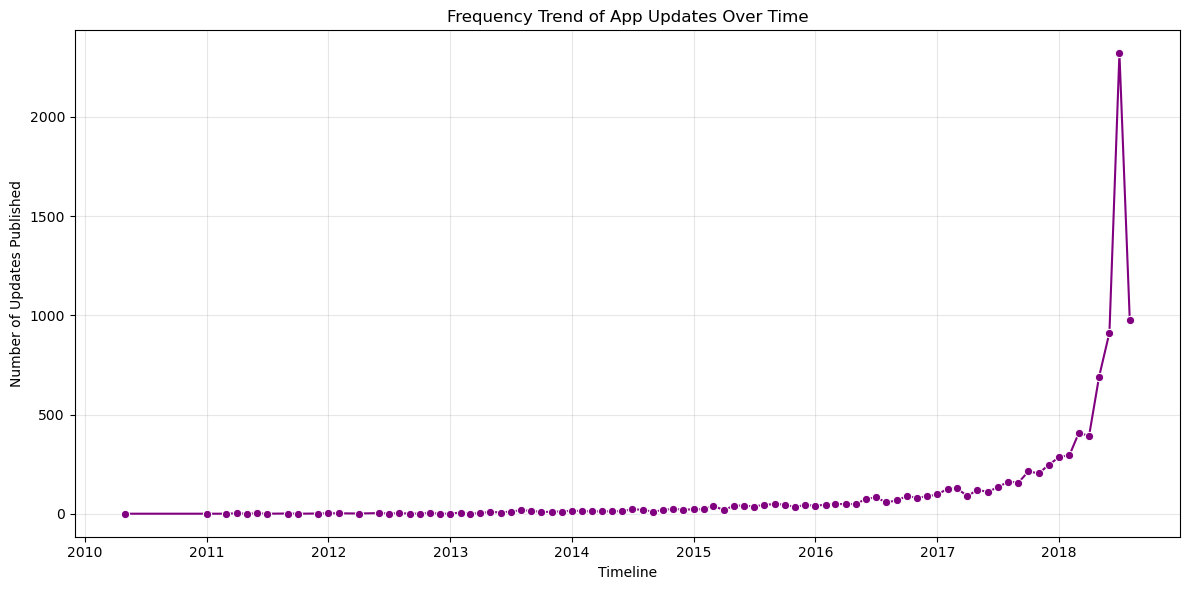

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print statement before the solution
print("Advanced Level - Topic 2: Trend of App Updates Over Time")

# Group data by year and month to track update frequency volume
update_trends = df.groupby(df['Last Updated'].dt.to_period('M')).size().reset_index(name='Count')
update_trends['Last Updated'] = update_trends['Last Updated'].dt.to_timestamp()

# Generate a time-series plot to visualize update velocity curves
plt.figure(figsize=(12, 6))
sns.lineplot(x='Last Updated', y='Count', data=update_trends, marker='o', color='purple')
plt.title('Frequency Trend of App Updates Over Time')
plt.xlabel('Timeline')
plt.ylabel('Number of Updates Published')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
import numpy as np

# Print statement before the solution
print("Advanced Level - Topic 3: Binned Analysis of Average Rating by Installation Volume")

# Define meaningful installation boundary bins based on your dataset metrics
install_bins = [0, 1000, 50000, 1000000, 50000000, np.inf]
bin_labels = ['<1k (Very Low)', '1k-50k (Low)', '50k-1M (Medium)', '1M-50M (High)', '50M+ (Mega Popular)']

# Partition the dataset into the defined installation brackets
df['Install_Bracket'] = pd.cut(df['Installs'], bins=install_bins, labels=bin_labels, include_lowest=True)

# Calculate the mean rating and total app count for each bracket
binned_analysis = df.groupby('Install_Bracket', observed=False).agg(
    Average_Rating=('Rating', 'mean'),
    Total_Apps=('App', 'count')
).reset_index()

print(binned_analysis)

Advanced Level - Topic 3: Binned Analysis of Average Rating by Installation Volume
       Install_Bracket  Average_Rating  Total_Apps
0       <1k (Very Low)        4.254701        2680
1         1k-50k (Low)        4.048018        1968
2      50k-1M (Medium)        4.172973        3034
3        1M-50M (High)        4.278293        1746
4  50M+ (Mega Popular)        4.370690         232


In [25]:
!pip install textblob

In [26]:
import pandas as pd
from textblob import TextBlob

# Print statement before the solution as requested
print("Advanced Level - Topic 4: Sentiment Analysis and Common Themes on App Reviews")

# Load your user reviews dataset
reviews_path = r"C:\Users\mukhe\OneDrive\Documents\Jobaaj_DA Projects\Google App Data Analysis\Dataset\googleplaystore_user_reviews.csv"
reviews_df = pd.read_csv(reviews_path)

# Drop rows where the review text is missing
reviews_df = reviews_df.dropna(subset=['Translated_Review'])

# Function to calculate sentiment polarity (-1 to 1)
def calculate_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

# Compute sentiment scores for the available review sample strings
reviews_df['Calculated_Polarity'] = reviews_df['Translated_Review'].apply(calculate_polarity)

# Merge with our main app dataframe to match ratings context
merged_reviews = pd.merge(reviews_df, df[['App', 'Rating']], on='App', how='inner')

# Segment into high-performing vs low-performing evaluation pools
high_rated_feedback = merged_reviews[merged_reviews['Rating'] >= 4.5]
low_rated_feedback = merged_reviews[merged_reviews['Rating'] <= 3.0]

print("\n--- High-Rated Apps (Rating >= 4.5) ---")
print(f"Average Review Polarity: {high_rated_feedback['Calculated_Polarity'].mean():.4f}")
print("Sample positive descriptors found:")
print(high_rated_feedback['Translated_Review'].head(3).values)

print("\n--- Low-Rated Apps (Rating <= 3.0) ---")
print(f"Average Review Polarity: {low_rated_feedback['Calculated_Polarity'].mean():.4f}")
print("Sample negative descriptors found:")
print(low_rated_feedback['Translated_Review'].head(3).values)

Advanced Level - Topic 4: Sentiment Analysis and Common Themes on App Reviews

--- High-Rated Apps (Rating >= 4.5) ---
Average Review Polarity: 0.2024
Sample positive descriptors found:
['Great hassle free way order contacts. Got call reminding prescription expires tomorrow.'
 "It's expensive I expected (I thought I'd saving money, cutting middle man), waaaaay convenient doctor's office."
 'Super fast navigation brand fast/easy checkout additional ads BS']

--- Low-Rated Apps (Rating <= 3.0) ---
Average Review Polarity: -0.0687
Sample negative descriptors found:
["Obviously like content terrible. If acorntv must crappy app, give us option casting content phone browsers. Instead forces us sucks. There many things wrong I can't even begin start listing all."
 "This update terrible! Loss function Chromecast Android. Being able go back forward button drop menu phone great I leave email, game Twitter I watch. Watchlist show anything recent, CC reliable, And support helpful all. It's even re

In [27]:
# Print statement before the solution
print("Advanced Level - Topic 5: Relationship Between App Genre and User Ratings")

# Group the data by Genres and compute the mean and median of the Rating column
genre_rating_analysis = df.groupby('Genres')['Rating'].agg(
    Mean_Rating='mean',
    Median_Rating='median',
    Total_Apps='count'
).sort_values(by='Mean_Rating', ascending=False)

# Display the top 15 highest-rated genres
print(genre_rating_analysis.head(15))

Advanced Level - Topic 5: Relationship Between App Genre and User Ratings
                                 Mean_Rating  Median_Rating  Total_Apps
Genres                                                                 
February 11, 2018                  19.000000          19.00           1
Comics;Creativity                   4.800000           4.80           1
Board;Pretend Play                  4.800000           4.80           1
Health & Fitness;Education          4.700000           4.70           1
Adventure;Brain Games               4.600000           4.60           1
Strategy;Action & Adventure         4.600000           4.60           2
Puzzle;Education                    4.600000           4.60           1
Entertainment;Creativity            4.533333           4.60           3
Music;Music & Video                 4.533333           4.60           3
Racing;Pretend Play                 4.500000           4.50           1
Tools;Education                     4.500000           4.50   